# Tune LightGBM (7-Day V3) with Optuna
This notebook tunes LightGBM on the `LGBM_XGB_7_V3` dataset using Optuna, then compares tuned vs untuned performance.

## 1) Imports and Paths

In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error

from lightgbm import LGBMRegressor

try:
    import optuna
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'optuna'])
    import optuna

RANDOM_SEED = 42
ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data' / 'processed' / 'LGBM_XGB_7_V3'
REPORTS_DIR = ROOT / 'artifacts' / 'reports'
MODELS_DIR  = ROOT / 'artifacts' / 'models'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print('DATA_DIR:', DATA_DIR)
print('REPORTS_DIR:', REPORTS_DIR)

DATA_DIR: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\data\processed\LGBM_XGB_7_V3
REPORTS_DIR: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\reports


## 2) Load Train/Val/Test

In [11]:
train_df = pd.read_csv(DATA_DIR / 'train.csv')
val_df   = pd.read_csv(DATA_DIR / 'val.csv')
test_df  = pd.read_csv(DATA_DIR / 'test.csv')

for df in [train_df, val_df, test_df]:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

summary = pd.DataFrame([
    {'split': 'train', 'rows': len(train_df), 'cols': train_df.shape[1], 'null_cells': int(train_df.isna().sum().sum())},
    {'split': 'val',   'rows': len(val_df),   'cols': val_df.shape[1],   'null_cells': int(val_df.isna().sum().sum())},
    {'split': 'test',  'rows': len(test_df),  'cols': test_df.shape[1],  'null_cells': int(test_df.isna().sum().sum())},
])
summary

,split,rows,cols,null_cells
0,train,68976,34,0
1,val,14370,34,0
2,test,15807,34,0


## 3) Features and Target

In [12]:
target_col = 'aggregated_sales_7'

feature_cols = [c for c in train_df.columns if c not in [
    target_col, 'date', 'item_id'
]]

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()
X_val   = val_df[feature_cols].copy()
y_val   = val_df[target_col].copy()
X_test  = test_df[feature_cols].copy()
y_test  = test_df[target_col].copy()

categorical_features = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(X_train[c])]
numeric_features     = [c for c in feature_cols if pd.api.types.is_numeric_dtype(X_train[c])]

print('Target:', target_col)
print('Feature count:', len(feature_cols))
print('Numeric:', len(numeric_features), '| Categorical:', len(categorical_features))

Target: aggregated_sales_7
Feature count: 31
Numeric: 31 | Categorical: 0


## 4) Helpers and Untuned Baseline
Untuned params carried over from Notebook 11.

In [13]:
def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred) + eps
    return float(100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom))

def compute_metrics(y_true, y_pred):
    return {
        'MAE':   float(mean_absolute_error(y_true, y_pred)),
        'RMSE':  float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'SMAPE': float(smape(y_true, y_pred)),
        'BIAS':  float(np.mean(np.asarray(y_pred) - np.asarray(y_true))),
    }

def make_lgbm_pipeline(model_kwargs):
    numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])
    preprocessor = ColumnTransformer(transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ])
    model = LGBMRegressor(random_state=RANDOM_SEED, **model_kwargs)
    return Pipeline(steps=[('prep', preprocessor), ('model', model)])

# Untuned baseline — exact params from Notebook 11
untuned_params = dict(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
)

untuned_lgbm = make_lgbm_pipeline(untuned_params)
untuned_lgbm.fit(X_train, y_train)

pred_untuned_val  = untuned_lgbm.predict(X_val)
pred_untuned_test = untuned_lgbm.predict(X_test)

baseline_val  = compute_metrics(y_val,  pred_untuned_val)
baseline_test = compute_metrics(y_test, pred_untuned_test)

pd.DataFrame([
    {'split': 'val',  'model': 'UntunedLGBM_7d', **baseline_val},
    {'split': 'test', 'model': 'UntunedLGBM_7d', **baseline_test},
])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016387 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3344
[LightGBM] [Info] Number of data points in the train set: 68976, number of used features: 29
[LightGBM] [Info] Start training from score 14.243998


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,split,model,MAE,RMSE,SMAPE,BIAS
0,val,UntunedLGBM_7d,4.960217,10.825014,75.682367,0.202480
1,test,UntunedLGBM_7d,5.034533,10.331738,67.385958,0.194516


## 5) Optuna Objective
Optimizes a normalized combined score across MAE, SMAPE, and RMSE — all three metrics matter.
Each metric is divided by the untuned baseline so they're on the same scale (~1.0 = no improvement).
MAE is weighted highest since it's our primary metric.

In [14]:
def objective(trial):
    params = {
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1),
        'n_estimators':      trial.suggest_int('n_estimators', 100, 1000),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'feature_fraction':  trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction':  trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'reg_alpha':         trial.suggest_float('reg_alpha',  1e-3, 10.0, log=True),
    }

    model = make_lgbm_pipeline(params)
    model.fit(X_train, y_train)

    preds_tr  = model.predict(X_train)
    preds_val = model.predict(X_val)

    mae_train  = mean_absolute_error(y_train, preds_tr)
    mae_val    = mean_absolute_error(y_val,   preds_val)
    rmse_val   = float(np.sqrt(mean_squared_error(y_val, preds_val)))
    smape_val  = smape(y_val, preds_val)

    # Normalize each metric by the untuned baseline so all are on the same scale
    # A value of 1.0 means no improvement; below 1.0 means better than untuned
    mae_norm   = mae_val   / baseline_val['MAE']
    rmse_norm  = rmse_val  / baseline_val['RMSE']
    smape_norm = smape_val / baseline_val['SMAPE']

    # Gap penalty: penalize overfitting (train-val gap), normalized by baseline MAE
    gap_penalty = abs(mae_val - mae_train) / baseline_val['MAE']

    # MAE weighted most (primary metric), SMAPE and RMSE contribute equally after it
    return float(0.50 * mae_norm + 0.25 * smape_norm + 0.15 * rmse_norm + 0.10 * gap_penalty)

## 6) Run Optuna Search

In [15]:
N_TRIALS = 60
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print('Best objective:', round(study.best_value, 4))
print('Best params:')
for k, v in study.best_params.items():
    print('  ' + k + ':', v)

  0%|          | 0/60 [00:00<?, ?it/s]

[LightGBM] [Warning] feature_fraction is set=0.5780093202212182, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5780093202212182
[LightGBM] [Warning] bagging_fraction is set=0.5779972601681014, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5779972601681014
[LightGBM] [Warning] feature_fraction is set=0.5780093202212182, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5780093202212182
[LightGBM] [Warning] bagging_fraction is set=0.5779972601681014, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5779972601681014
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025198 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3344
[LightGBM] [Info] Number of data points in the train set: 68976, number of used features: 29
[LightGBM] [Info] Start training from score 14.243998


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.5780093202212182, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5780093202212182
[LightGBM] [Warning] bagging_fraction is set=0.5779972601681014, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5779972601681014


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Best trial: 0. Best value: 0.944614:   0%|          | 0/60 [00:05<?, ?it/s]

...

[LightGBM] [Warning] feature_fraction is set=0.6044120493957252, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6044120493957252
[LightGBM] [Warning] bagging_fraction is set=0.5294878242186694, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5294878242186694
[LightGBM] [Warning] feature_fraction is set=0.6044120493957252, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6044120493957252
[LightGBM] [Warning] bagging_fraction is set=0.5294878242186694, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5294878242186694
[LightGBM] [Warning] feature_fraction is set=0.6460973796571982, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6460973796571982
[LightGBM] [Warning] bagging_fraction is set=0.7016577721717902, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7016577721717902
[LightGBM] [Warning] feature_fraction is set=0.6460973796571982, colsample_bytree=1.0 will be ign

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Best trial: 26. Best value: 0.893257:  98%|█████████▊| 59/60 [02:16<00:01,  1.46s/it]

[LightGBM] [Warning] feature_fraction is set=0.6460973796571982, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6460973796571982
[LightGBM] [Warning] bagging_fraction is set=0.7016577721717902, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7016577721717902
[LightGBM] [Warning] feature_fraction is set=0.6460973796571982, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6460973796571982
[LightGBM] [Warning] bagging_fraction is set=0.7016577721717902, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7016577721717902


Best trial: 26. Best value: 0.893257: 100%|██████████| 60/60 [02:16<00:00,  2.28s/it]

Best objective: 0.8933
Best params:
  num_leaves: 76
  learning_rate: 0.0176883065105201
  n_estimators: 350
  min_child_samples: 43
  feature_fraction: 0.6865867534078534
  bagging_fraction: 0.6539685665916231
  reg_lambda: 0.0015025306473817233
  reg_alpha: 0.7331350060244777


## 7) Train Tuned Model and Compare vs Untuned

In [16]:
best_params = study.best_params.copy()
tuned_lgbm  = make_lgbm_pipeline(best_params)
tuned_lgbm.fit(X_train, y_train)

pred_tuned_val  = tuned_lgbm.predict(X_val)
pred_tuned_test = tuned_lgbm.predict(X_test)

tuned_val  = compute_metrics(y_val,  pred_tuned_val)
tuned_test = compute_metrics(y_test, pred_tuned_test)

metrics_rows = [
    {'split': 'val',  'model': 'UntunedLGBM_7d', **baseline_val},
    {'split': 'test', 'model': 'UntunedLGBM_7d', **baseline_test},
    {'split': 'val',  'model': 'TunedLGBM_7d',   **tuned_val},
    {'split': 'test', 'model': 'TunedLGBM_7d',   **tuned_test},
]
metrics_df = pd.DataFrame(metrics_rows)
metrics_df['BIAS_abs'] = metrics_df['BIAS'].abs()
metrics_df = metrics_df[['split', 'model', 'MAE', 'RMSE', 'SMAPE', 'BIAS', 'BIAS_abs']]

gap_rows = []
for model_name in metrics_df['model'].unique():
    tmp = metrics_df[metrics_df['model'] == model_name].set_index('split')
    gap_rows.append({
        'model':          model_name,
        'MAE_gap_abs':   abs(tmp.loc['test', 'MAE']   - tmp.loc['val', 'MAE']),
        'RMSE_gap_abs':  abs(tmp.loc['test', 'RMSE']  - tmp.loc['val', 'RMSE']),
        'SMAPE_gap_abs': abs(tmp.loc['test', 'SMAPE'] - tmp.loc['val', 'SMAPE']),
    })
gap_df = pd.DataFrame(gap_rows)

display(metrics_df.sort_values(['split', 'MAE']))
display(gap_df.sort_values('MAE_gap_abs'))

[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012852 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3344
[LightGBM] [Info] Number of data points in the train set: 68976, number of used features: 29
[LightGBM] [Info] Start training from score 14.243998
[LightGBM] [Warning] feature_fraction is set=0.68658675

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,split,model,MAE,RMSE,SMAPE,BIAS,BIAS_abs
3,test,TunedLGBM_7d,4.905664,9.694002,66.421990,-0.160455,0.160455
1,test,UntunedLGBM_7d,5.034533,10.331738,67.385958,0.194516,0.194516
2,val,TunedLGBM_7d,4.877129,10.379040,74.963555,-0.142167,0.142167
0,val,UntunedLGBM_7d,4.960217,10.825014,75.682367,0.202480,0.202480


,model,MAE_gap_abs,RMSE_gap_abs,SMAPE_gap_abs
1,TunedLGBM_7d,0.028535,0.685038,8.541564
0,UntunedLGBM_7d,0.074316,0.493276,8.296410


## 8) Actual vs Predicted (Test)

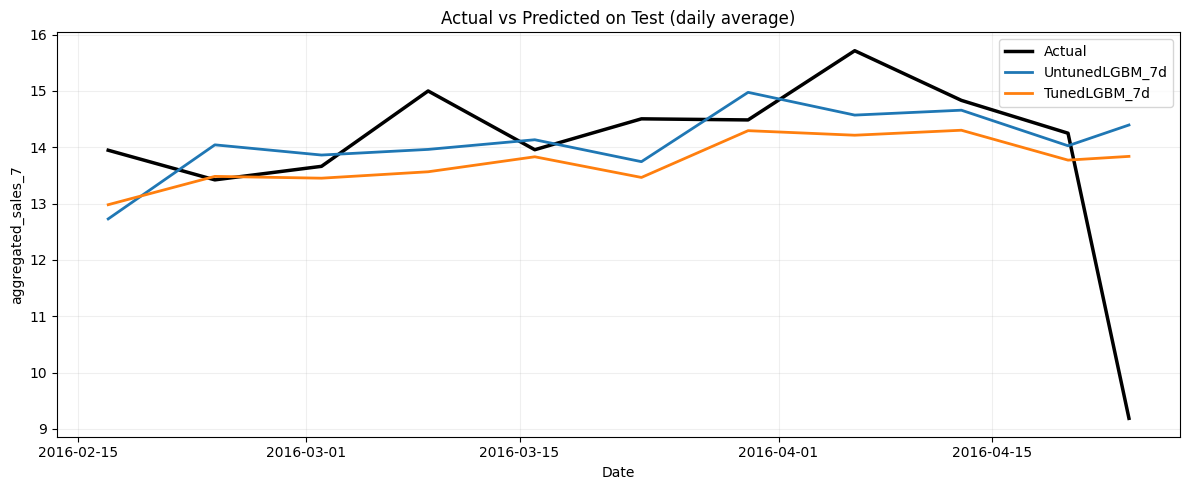

In [17]:
curve_df = test_df[['date']].copy()
curve_df['actual']  = y_test.values
curve_df['untuned'] = pred_untuned_test
curve_df['tuned']   = pred_tuned_test
curve_df = curve_df.groupby('date', as_index=False).mean(numeric_only=True).sort_values('date')

plt.figure(figsize=(12, 5))
plt.plot(curve_df['date'], curve_df['actual'],  label='Actual',         color='black', linewidth=2.5)
plt.plot(curve_df['date'], curve_df['untuned'], label='UntunedLGBM_7d', linewidth=2)
plt.plot(curve_df['date'], curve_df['tuned'],   label='TunedLGBM_7d',   linewidth=2)
plt.title('Actual vs Predicted on Test (daily average)')
plt.xlabel('Date')
plt.ylabel('aggregated_sales_7')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 9) Residual Distribution (Test)

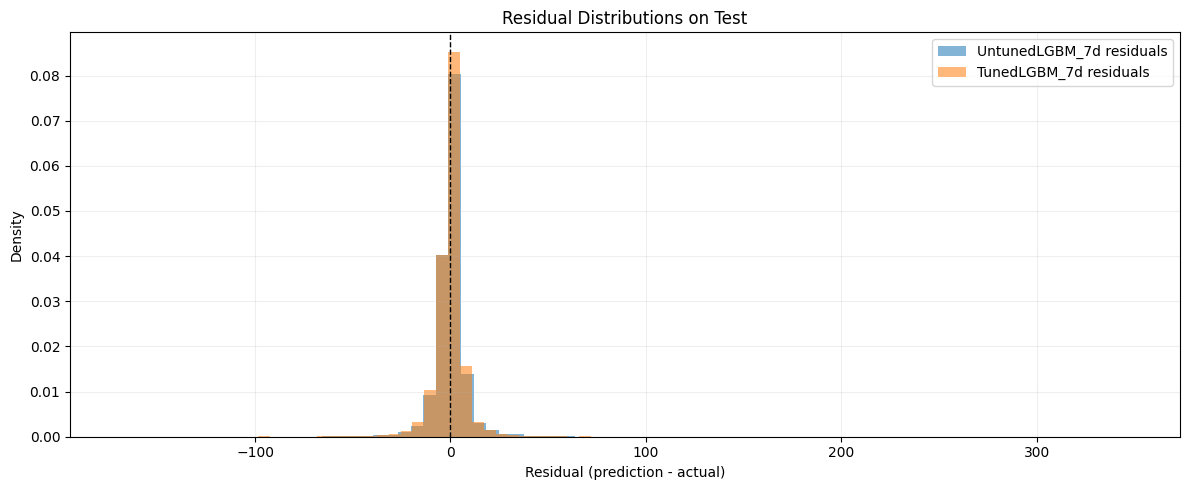

In [18]:
res_untuned = pred_untuned_test - y_test.values
res_tuned   = pred_tuned_test   - y_test.values

plt.figure(figsize=(12, 5))
plt.hist(res_untuned, bins=80, alpha=0.55, density=True, label='UntunedLGBM_7d residuals')
plt.hist(res_tuned,   bins=80, alpha=0.55, density=True, label='TunedLGBM_7d residuals')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Residual Distributions on Test')
plt.xlabel('Residual (prediction - actual)')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 10) Save Metrics and Predictions

In [20]:
import json, joblib

# Save metrics comparison table
metrics_df.to_csv(REPORTS_DIR / 'metrics_lgbm_7d_tuned_vs_untuned.csv', index=False)
gap_df.to_csv(REPORTS_DIR / 'metrics_lgbm_7d_val_test_gap.csv', index=False)

# Save test predictions
preds_out = test_df[['item_id', 'date']].copy()
preds_out['actual']       = y_test.values
preds_out['pred_untuned'] = pred_untuned_test
preds_out['pred_tuned']   = pred_tuned_test
preds_out.to_csv(REPORTS_DIR / 'predictions_lgbm_7d_tuned_vs_untuned_test.csv', index=False)

# Save best params to reports
with open(REPORTS_DIR / 'best_params_lgbm_7d_optuna.json', 'w') as f:
    json.dump(best_params, f, indent=2)

# Save tuned model and updated params to artifacts/models (overwrites old version)
joblib.dump(tuned_lgbm, MODELS_DIR / 'tuned_lgbm_7_v3.joblib')
with open(MODELS_DIR / 'tuned_lgbm_7_v3_best_params.json', 'w') as f:
    json.dump(best_params, f, indent=2)

print('Saved metrics:     ', REPORTS_DIR / 'metrics_lgbm_7d_tuned_vs_untuned.csv')
print('Saved predictions: ', REPORTS_DIR / 'predictions_lgbm_7d_tuned_vs_untuned_test.csv')
print('Saved model:       ', MODELS_DIR  / 'tuned_lgbm_7_v3.joblib')
print('Saved params:      ', MODELS_DIR  / 'tuned_lgbm_7_v3_best_params.json')

Saved metrics:      C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\reports\metrics_lgbm_7d_tuned_vs_untuned.csv
Saved predictions:  C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\reports\predictions_lgbm_7d_tuned_vs_untuned_test.csv
Saved model:        C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\models\tuned_lgbm_7_v3.joblib
Saved params:       C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\models\tuned_lgbm_7_v3_best_params.json
